<a href="https://colab.research.google.com/github/Ruchirr999/csot-ml-astronomy/blob/main/submissions/Ruchirr999/week3/week3_eval_starter_submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSoT'26 - ML in Astronomy - Week 3 . Part 2: Evaluation and Interpretation (Starter)

**Goal:** Evaluate the CNN honestly. Track train-vs-validation loss, report a **test accuracy** that beats the Week-2 baseline, build a **confusion matrix** you can read astrophysically, and **save** the trained weights.

**Before you begin:**
1. Switch this notebook to a **GPU runtime** (`Runtime -> Change runtime type -> GPU`).
2. Read [`05-evaluation-and-overfitting.md`](../05-evaluation-and-overfitting.md), [`06-confusion-matrix-and-metrics.md`](../06-confusion-matrix-and-metrics.md), and [`07-saving-and-loading-models.md`](../07-saving-and-loading-models.md).

Replace each `TODO`. **Do not** open the solution until you've genuinely attempted every TODO.

## Step 0 - Data + model

Re-create the Week-1 `DataLoader`s and your `GalaxyCNN` (paste both from Part 1). You can either re-train here, or load Part 1's `galaxy_model.pth`. After this section you need: `train_loader`, `val_loader`, `test_loader`, `test_ds`, `num_classes`, `model`, `criterion`, `optimizer`.

In [1]:
import math
import os
import random
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [2]:
# TODO: paste the Week-1 data pipeline AND your GalaxyCNN definition from Part 1, so that
#   train_loader, val_loader, test_loader, test_ds, num_classes, model, criterion, optimizer
# are all defined. Move model to device. (Optionally load Part-1 weights:
#   model.load_state_dict(torch.load('galaxy_model.pth', map_location=device)) )
# TODO: paste your Week 1 data pipeline here so that the following names are defined:
#   train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, num_classes
#
# The quickest path is to copy the data-prep cells from
# ../../Week-1/notebooks/week1_data_solution.ipynb (Steps 1-8), then add:
#   num_classes = len(train_ds.classes)
#   print("classes:", train_ds.classes, "num_classes:", num_classes)
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2/images"   # adjust if your JPGs landed one folder deeper
DATA_ROOT = Path("galaxy_data")        # we create train/val/test subfolders here
LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"


# Download Galaxy Zoo 2 images dataset
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images
# Create raw data folder
!mkdir -p galaxy_raw
# Unzip dataset
!unzip -q galaxy-zoo-2-images.zip -d galaxy_raw
# Download Hart et al. labels
!wget -q -O galaxy_raw/gz2_hart16.csv.gz \
https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
# Unzip labels csv
!gunzip -f galaxy_raw/gz2_hart16.csv.gz

print("RAW_ROOT   =", RAW_ROOT)
print("IMAGES_DIR =", IMAGES_DIR)
print("DATA_ROOT  =", DATA_ROOT)

print("RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))
jpg_count = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
print(f"Flat JPG count in {IMAGES_DIR}: {jpg_count:,}")

print("\nMapping CSV preview:")
print(pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv", nrows=3))

print("\nLabels CSV preview (note dr7objid — we rename to objid before merging):")
print(pd.read_csv(RAW_ROOT / "gz2_hart16.csv", nrows=3)[["dr7objid", "gz2_class"]])

def high_level_label(gz2_class: str):
    """Collapse detailed GZ2 codes (Sc2t, Ei, SBb2m, …) to a few training buckets."""
    if not isinstance(gz2_class, str) or gz2_class == "A":
        return None  # artifact / ambiguous
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None
def load_labeled_table(mapping_csv, labels_csv):
    """Join Kaggle mapping (objid ↔ asset_id) with Hart et al. morphology labels."""
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv)
    if "dr7objid" in labels.columns:
        labels = labels.rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"]).reset_index(drop=True)
    return df


def _link_image(src: Path, dst: Path) -> bool:
    """Symlink if possible; otherwise copy (some Drive setups block symlinks)."""
    if dst.exists():
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.symlink(src.resolve(), dst)
    except OSError:
        import shutil
        shutil.copy2(src, dst)
    return True

def build_split_imagefolder_layout(
    images_dir,
    df,
    out_root,
    per_class=200,
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    seed=42,
):
    """Create out_root/{train,val,test}//*.jpg for ImageFolder."""
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6
    images_dir = Path(images_dir)
    out_root = Path(out_root)
    summary = {}

    for label in sorted(df["label"].unique()):
        rows = df[df["label"] == label].sample(frac=1, random_state=seed)
        if len(rows) > per_class:
            rows = rows.head(per_class)

        n = len(rows)
        n_train = int(train_frac * n)
        n_val = int(val_frac * n)
        n_test = n - n_train - n_val
        splits = {
            "train": rows.iloc[:n_train],
            "val": rows.iloc[n_train : n_train + n_val],
            "test": rows.iloc[n_train + n_val :],
        }

        summary[label] = {}
        for split_name, split_rows in splits.items():
            linked = 0
            for _, row in split_rows.iterrows():
                src = images_dir / f"{int(row.asset_id)}.jpg"
                dst = out_root / split_name / label / f"{int(row.asset_id)}.jpg"
                if src.exists() and _link_image(src, dst):
                    linked += 1
            summary[label][split_name] = linked
    return summary

df = load_labeled_table(
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
)
print("Joined rows:", len(df))
print("\nLabel counts:")
print(df["label"].value_counts())
print("\nExample rows:")
print(df[["asset_id", "objid", "gz2_class", "label"]].head())
PER_CLASS = 2000  # increase once the pipeline works (e.g. 2000)

summary = build_split_imagefolder_layout(
    IMAGES_DIR,
    df,
    DATA_ROOT,
    per_class=PER_CLASS,
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    seed=42,
)
print("Linked images per class and split:")
print(pd.DataFrame(summary).fillna(0).astype(int))

for split in ("train", "val", "test"):
    split_dir = DATA_ROOT / split
    classes = sorted(p.name for p in split_dir.iterdir() if p.is_dir()) if split_dir.exists() else []
    n_imgs = sum(1 for _ in split_dir.rglob("*.jpg")) if split_dir.exists() else 0
    print(f"{split:5s}: {n_imgs:4d} images  classes={classes}")
# Randomly alter the training images to prevent memorization
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomRotation(degrees=45),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Do NOT alter the validation/test images!
eval_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_ds = ImageFolder(root=DATA_ROOT / "train", transform=train_transform)
val_ds   = ImageFolder(root=DATA_ROOT / "val",   transform=eval_transform)
test_ds  = ImageFolder(root=DATA_ROOT / "test",  transform=eval_transform)

for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    print(f"{name:5s}  n={len(ds):4d}  classes={ds.classes}")

print("class_to_idx:", train_ds.class_to_idx)
image, label = train_ds[0]
print("shape :", image.shape)
print("dtype :", image.dtype)
print("label :", label, "->", train_ds.classes[label])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

images, labels = next(iter(train_loader))
print("train batch images:", images.shape)   # (32, 3, 64, 64)
print("train batch labels:", labels.shape)     # (32,)

num_classes = len(train_ds.classes)
print("classes:", train_ds.classes, "num_classes:", num_classes)
class GalaxyCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Define the feature extractor
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Define the classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = GalaxyCNN(num_classes=num_classes).to(device)
print(model)
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

#       logits = model(images); print(logits.shape)  # expect (B, num_classes)
logits = model(images)
print(logits.shape)

#       total = sum(p.numel() for p in model.parameters()); print(f"params: {total:,}")
total = sum(p.numel() for p in model.parameters())
print(f"params: {total:,}")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
#       loss = criterion(logits, labels); print(loss.item(), "vs ln(C) =", math.log(num_classes))
loss = criterion(logits, labels)
print(loss.item(), "vs ln(C) =", math.log(num_classes))
# TODO: write the training loop.


torch.save(model.state_dict(), 'galaxy_model.pth')
print('saved')

Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [00:27<00:00, 118MB/s]

RAW_ROOT   = galaxy_raw
IMAGES_DIR = galaxy_raw/images_gz2/images
DATA_ROOT  = galaxy_data
RAW_ROOT contents: ['gz2_filename_mapping.csv', 'gz2_hart16.csv', 'images_gz2']
Flat JPG count in galaxy_raw/images_gz2/images: 243,434

Mapping CSV preview:
                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3

Labels CSV preview (note dr7objid — we rename to objid before merging):
             dr7objid gz2_class
0  587732591714893851      Sc+t
1  588009368545984617      Sb+t
2  587732484359913515        Ei
Joined rows: 239100

Label counts:
label
elliptical       97670
spiral           95849
spiral_barred    45581
Name: count, dtype: int64

Example rows:
   asset_id               objid gz2_class       label
0    

## Step 1 - The evaluation function

Write `evaluate(model, loader, criterion, device)` that returns `(avg_loss, accuracy)`. It MUST use `model.eval()` and `torch.no_grad()`. Predicted class = `outputs.argmax(dim=1)`.

In [3]:
# TODO: define evaluate(model, loader, criterion, device):
#   model.eval(); total_loss=correct=total=0
#   with torch.no_grad():
#       for inputs, targets in loader:
#           inputs, targets = inputs.to(device), targets.to(device)
#           outputs = model(inputs); loss = criterion(outputs, targets)
#           total_loss += loss.item() * inputs.size(0)
#           preds = outputs.argmax(dim=1)
#           correct += (preds == targets).sum().item(); total += targets.size(0)
#   return total_loss/total, correct/total


def evaluate(model, loader, criterion, device):
    # Set model to evaluation mode
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    # Disable gradient computation
    with torch.no_grad():
        for inputs, targets in loader:
            # Move data to the designated device (GPU or CPU)
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            # Track loss and metrics
            total_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

    # Calculate averages
    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


## Step 2 - Train while tracking validation

Run the training loop again, but each epoch also call `evaluate(model, val_loader, ...)`. Record `train_losses` and `val_losses` (and optionally `val_accs`).

In [4]:

train_losses, val_losses, val_accs = [], [], []
num_epochs=24; train_losses=[]; val_losses=[]
for epoch in range(num_epochs):
    model.train(); running=0.0
    for inputs, targets in train_loader:

      inputs, targets = inputs.to(device), targets.to(device)
      optimizer.zero_grad(); out=model(inputs); loss=criterion(out, targets)
      loss.backward(); optimizer.step(); running += loss.item()*inputs.size(0)
    train_losses.append(running/len(train_loader.dataset))
    vl, va = evaluate(model, val_loader, criterion, device)
    val_losses.append(vl)
    print(f"epoch {epoch+1}: train {train_losses[-1]:.3f}  val {vl:.3f}  val_acc {va:.3f}")

epoch 1: train 1.080  val 1.031  val_acc 0.451
epoch 2: train 1.000  val 0.986  val_acc 0.478
epoch 3: train 0.990  val 0.971  val_acc 0.492
epoch 4: train 0.957  val 0.950  val_acc 0.508
epoch 5: train 0.941  val 0.941  val_acc 0.553
epoch 6: train 0.922  val 0.903  val_acc 0.581
epoch 7: train 0.908  val 0.927  val_acc 0.539
epoch 8: train 0.905  val 0.904  val_acc 0.570
epoch 9: train 0.877  val 0.892  val_acc 0.586
epoch 10: train 0.873  val 0.878  val_acc 0.587
epoch 11: train 0.856  val 0.877  val_acc 0.604
epoch 12: train 0.852  val 0.865  val_acc 0.611
epoch 13: train 0.849  val 0.864  val_acc 0.602
epoch 14: train 0.836  val 0.851  val_acc 0.610
epoch 15: train 0.826  val 0.870  val_acc 0.601
epoch 16: train 0.826  val 0.852  val_acc 0.600
epoch 17: train 0.813  val 0.832  val_acc 0.616
epoch 18: train 0.822  val 0.841  val_acc 0.624
epoch 19: train 0.797  val 0.834  val_acc 0.614
epoch 20: train 0.806  val 0.843  val_acc 0.608
epoch 21: train 0.788  val 0.850  val_acc 0.618
e

## Step 3 - Plot train vs validation loss

Plot both on one axis. A widening gap (train falling, val rising) is the overfitting signature.

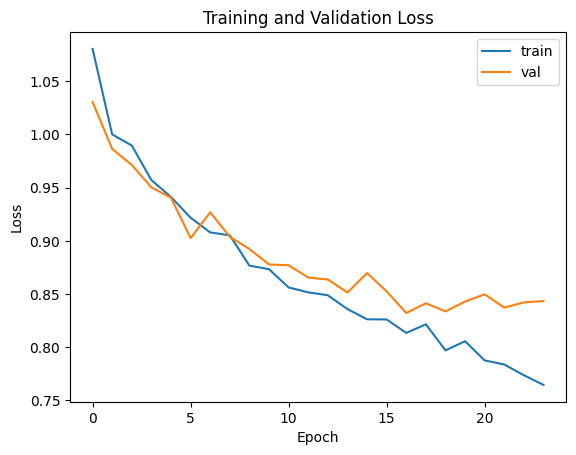

In [5]:
# TODO: plt.plot(train_losses, label='train'); plt.plot(val_losses, label='val')
#       label axes; legend; title; show. Then comment (Markdown) on overfitting.
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

## Step 4 - Final test accuracy vs the Week-2 baseline

Evaluate ONCE on the test set. State your Week-2 baseline number and the improvement.

In [6]:
# TODO: test_loss, test_acc = evaluate(model, test_loader, criterion, device)
#       print(f"test accuracy: {test_acc:.3f}")
#       baseline = ...  # your Week-2 KNN/LogReg test accuracy
#       print(f"beat baseline by {test_acc - baseline:+.3f}")
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"test accuracy: {test_acc:.3f}")
baseline = 0.4666666666666667
print(f"beat baseline by {test_acc - baseline:+.3f}")

test accuracy: 0.607
beat baseline by +0.140


## Step 5 - Confusion matrix

Collect predictions across the test set (move them to CPU before NumPy!), then display a labelled confusion matrix using `test_ds.classes`.

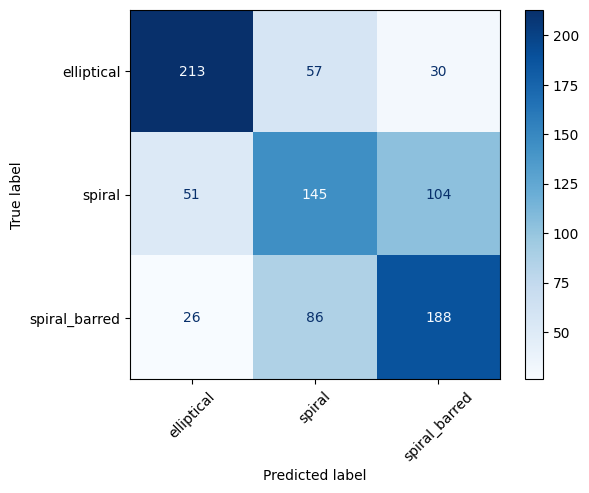

In [7]:
# TODO: model.eval(); all_preds=[]; all_labels=[]
#   with torch.no_grad():
#       for inputs, targets in test_loader:
#           preds = model(inputs.to(device)).argmax(dim=1).cpu()
#           all_preds.append(preds); all_labels.append(targets)
#   y_pred = torch.cat(all_preds).numpy(); y_true = torch.cat(all_labels).numpy()
#   cm = confusion_matrix(y_true, y_pred)
#   ConfusionMatrixDisplay(cm, display_labels=test_ds.classes).plot(cmap='Blues', xticks_rotation=45)
#   plt.show()
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, targets in test_loader:
        preds = model(inputs.to(device)).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(targets)

y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_labels).numpy()

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=test_ds.classes).plot(cmap='Blues', xticks_rotation=45)
plt.show()


## Step 6 - Per-class report + astrophysical reading

Print `classification_report`, then in a Markdown cell name the most-confused pair and link it to the astronomy (density waves / bars in [`04`](../04-spiral-structure-and-star-formation.md); lenticulars / mergers in [`08`](../08-lenticulars-mergers-and-evolution.md)).

In [9]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=test_ds.classes))


               precision    recall  f1-score   support

   elliptical       0.73      0.71      0.72       300
       spiral       0.50      0.48      0.49       300
spiral_barred       0.58      0.63      0.60       300

     accuracy                           0.61       900
    macro avg       0.61      0.61      0.61       900
 weighted avg       0.61      0.61      0.61       900



## Step 7 - Save and reload (round-trip check)

Save the `state_dict`, load it into a fresh `GalaxyCNN`, and assert the reloaded test accuracy matches the original.

In [10]:
# TODO: torch.save(model.state_dict(), 'galaxy_model.pth')
#   loaded = GalaxyCNN(num_classes=num_classes).to(device)
#   loaded.load_state_dict(torch.load('galaxy_model.pth', map_location=device)); loaded.eval()
#   _, acc2 = evaluate(loaded, test_loader, criterion, device)
#   assert abs(acc2 - test_acc) < 1e-6; print('round-trip verified:', acc2)
torch.save(model.state_dict(), 'galaxy_model.pth')
loaded = GalaxyCNN(num_classes=num_classes).to(device)
loaded.load_state_dict(torch.load('galaxy_model.pth', map_location=device)); loaded.eval()
_, acc2 = evaluate(loaded, test_loader, criterion, device)
assert abs(acc2 - test_acc) < 1e-6; print('round-trip verified:', acc2)


round-trip verified: 0.6066666666666667


## Reflection *(write 2-3 sentences each)*

1. What test accuracy did you reach, and by how much did the CNN beat the Week-2 baseline?
2. Did your curves show overfitting? How could you tell, and what would you try next?
3. Which two classes were confused most, and is that a model failure, a real physical ambiguity, or both?
4. Why is the save/reload round-trip check worth running rather than assuming it worked?

*(Replace this prompt with your answers.)*